In [1]:
import sys
sys.path.append("../../")

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from dextramixer.utils import dist_to_sim
from dextramixer.model import DextraMixer, BEAMT
import muon as mu
import scirpy as ir
import scanpy as sc
import matplotlib.pyplot as plt
import jax.numpy as jnp

/Users/benjamin.schubert/miniforge3/envs/sc/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
mdat = mu.read("../../data/02_dex_annotated_cd8.h5ad")
mdat

In [ ]:
mdat2 = ir.io.upgrade_schema(mdat)

In [ ]:
gex_obs = ['experiment', 'donor','sample']
airr_obs = ['binding_10x', 'binding_ct', 'clone_id',  'clone_id_size', 
            'clone_size', 'clonotype_sequence']
airr_uns = ["clonotype_sequence_dict", "ir_dist_aa_identity"]

In [ ]:
adata_gex = sc.AnnData(mdat.X)
adata_dex = sc.AnnData(mdat.obs[mdat.uns["epitopes"]])
for g in gex_obs:
    adata_gex.obs[g] = mdat.obs[g]
    adata_dex.obs[g] = mdat.obs[g]
adata_dex.var['gene_ids'] = mdat.uns["epitopes"]
adata_gex.var['gene_ids'] = mdat.var.gene_ids

adata_ir = sc.AnnData()
for a in airr_obs:
    adata_ir.obs[a] = mdat.obs[a]

for a in airr_uns:
    adata_ir.uns[a] = mdat.uns[a]
adata_ir.obsm["airr"] = mdat.obsm['airr']

mdata = mu.MuData({"gex":adata_gex, "dex":adata_dex, "airr":adata_ir})
mdata

# Filtering

In [ ]:
ir.pp.index_chains(mdata)
ir.tl.chain_qc(mdata)

In [ ]:
mu.pp.filter_obs(mdata, "airr:chain_pairing", lambda x: x != "multichain")
mu.pp.filter_obs(mdata, "airr:chain_pairing", lambda x: ~np.isin(x, ["orphan VDJ", "orphan VJ"]))


In [ ]:
mdata.mod["airr"].obs["clone_id_felix"] = mdata.mod["airr"].obs["clone_id"]

In [ ]:
ir.pp.ir_dist(mdata)
ir.tl.define_clonotypes(mdata, receptor_arms="all", dual_ir="primary_only")

In [ ]:
ir.tl.clonotype_network(mdata, min_cells=2)

In [ ]:
# remove cells without clonotype information
mu.pp.filter_obs(mdata, "airr:clone_id", lambda x:  x != 'nan')

# Example LTDEMIAQY

In [3]:
experiment = "third_experiment"

In [ ]:


mdat_LTD = mdata[:,"LTDEMIAQY"].copy()
mu.pp.filter_obs(mdat_LTD, "dex:experiment", lambda x: np.isin(x, [experiment]))

ir.pp.ir_dist(
    mdat_LTD,
    metric="alignment",
    sequence="aa",
    cutoff=255,
)

ir.tl.define_clonotype_clusters(mdat_LTD, sequence="aa", metric="alignment", receptor_arms="all", dual_ir="primary_only")
dist = (mdat_LTD.mod["airr"].uns["cc_aa_alignment"]["distances"].todense() - 1).astype("float64")

In [ ]:
mdat_LTD.mod["airr"].uns["cc_aa_alignment"]
cc_clone_id = {"cell_id": [], "clone_id":[]}
for c_id, umi_list in mdat_LTD.mod["airr"].uns["cc_aa_alignment"]["cell_indices"].items():
    for umi in umi_list:
        cc_clone_id["clone_id"].append(c_id)
        cc_clone_id["cell_id"].append(umi)
df_cc_clone_id = pd.Series(data=cc_clone_id["clone_id"], index=cc_clone_id["cell_id"])
mdat_LTD.mod["airr"].obs["cc_aa_clone_id"] = df_cc_clone_id

In [ ]:
from dextramixer.utils import dist_to_sim
mdat_LTD.mod['airr'].uns["ir_alignment_cov"] = np.asarray(dist_to_sim(dist))

In [ ]:
mdat_LTD.write("mdat_LTD_{}.h5mu".format(experiment))

# Inference

In [4]:
mdat_LTD = mu.read("mdat_LTD_{}.h5mu".format(experiment))
mdat_LTD

/Users/benjamin.schubert/miniforge3/envs/sc/lib/python3.10/site-packages/anndata/utils.py:334: ExperimentalFeatureWarning: Support for Awkward Arrays is currently experimental. Behavior may change in the future. Please report any issues you may encounter!
  warnings.warn(msg, category, stacklevel=stacklevel)
/Users/benjamin.schubert/miniforge3/envs/sc/lib/python3.10/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/Users/benjamin.schubert/miniforge3/envs/sc/lib/python3.10/site-packages/anndata/_core/anndata.py:430: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


MuData object with n_obs × n_vars = 11749 × 1
  3 modalities
    gex:	0 x 0
      obs:	'experiment', 'donor', 'sample'
      var:	'gene_ids'
    dex:	11749 x 1
      obs:	'experiment', 'donor', 'sample'
      var:	'gene_ids'
    airr:	11749 x 0
      obs:	'binding_10x', 'binding_ct', 'clone_id', 'clone_id_size', 'clone_size', 'clonotype_sequence', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id_felix', 'cc_aa_alignment', 'cc_aa_alignment_size', 'cc_aa_clone_id', 'p_H_Cov', 'assignment_H_Cov', 'p_I_Clone', 'assignment_I_Clone', 'p_mixturemodel_H_clone_id', 'assignment_mixturemodel_H_clone_id', 'p_mixturemodel_H_None', 'assignment_mixturemodel_H_None', 'p_mixturemodel_I_clone_id', 'assignment_mixturemodel_I_clone_id', 'p_mixturemodel_I_None', 'assignment_mixturemodel_I_None', 'p_mixturemodel_C_clone_id', 'assignment_mixturemodel_C_clone_id', 'p_mixturemodelkmeans_H_clone_id', 'assignment_mixturemodelkmeans_H_clone_id', 'p_mixturemodelkmeans_H_None', 'assignment_mixturemodelkmeans_H_None', 'p_mixturemodelkmeans_I_clone_id', 'assignment_mixturemodelkmeans_I_clone_id', 'p_mixturemodelkmeans_I_None', 'assignment_mixturemodelkmeans_I_None', 'p_mixturemodelkmeans_C_clone_id', 'assignment_mixturemodelkmeans_C_clone_id'
      uns:	'H_cov_summary', 'I_Clone_summary', 'cc_aa_alignment', 'chain_indices', 'clone_id', 'clonotype_network', 'clonotype_sequence_dict', 'ir_alignment_cov', 'ir_dist_aa_alignment', 'ir_dist_aa_identity', 'ir_dist_nt_identity', 'metrics_mixturemodel_C_clone_id', 'metrics_mixturemodel_H_None', 'metrics_mixturemodel_H_clone_id', 'metrics_mixturemodel_I_None', 'metrics_mixturemodel_I_clone_id', 'metrics_mixturemodelkmeans_C_clone_id', 'metrics_mixturemodelkmeans_H_None', 'metrics_mixturemodelkmeans_H_clone_id', 'metrics_mixturemodelkmeans_I_None', 'metrics_mixturemodelkmeans_I_clone_id', 'summary_mixturemodel_C_clone_id', 'summary_mixturemodel_H_None', 'summary_mixturemodel_H_clone_id', 'summary_mixturemodel_I_None', 'summary_mixturemodel_I_clone_id', 'summary_mixturemodelkmeans_C_clone_id', 'summary_mixturemodelkmeans_H_None', 'summary_mixturemodelkmeans_H_clone_id', 'summary_mixturemodelkmeans_I_None', 'summary_mixturemodelkmeans_I_clone_id'
      obsm:	'X_clonotype_network', 'airr', 'chain_indices'

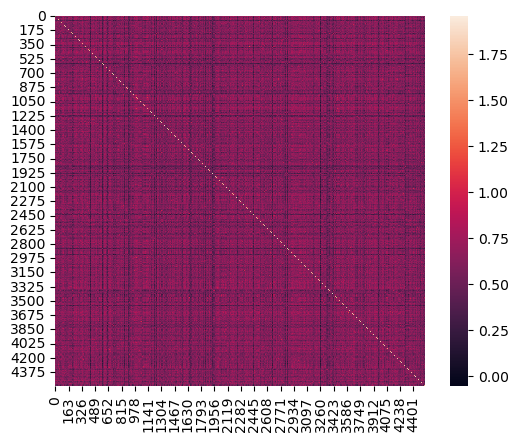

In [5]:
sns.heatmap(mdat_LTD.mod['airr'].uns["ir_alignment_cov"],square=True);

In [6]:
mdat_LTD.mod["airr"].obs.clone_id_size

cell_id
AAACCTGAGATTACCC-1-0-1      19
AAACCTGAGGTCGGAT-1-0-1      10
AAACCTGCAATAGCGG-1-0-1       1
AAACCTGCATTCCTCG-1-0-1       1
AAACCTGGTACCCAAT-1-0-1       1
                          ... 
TTTGCGCTCTCTGAGA-1-2-1       1
TTTGGTTGTTCGGGCT-1-2-1       5
TTTGGTTTCCACGACG-1-2-1    1090
TTTGTCACAGCTGCAC-1-2-1    1090
TTTGTCATCCTATGTT-1-2-1      16
Name: clone_id_size, Length: 11749, dtype: int64

In [ ]:
df = pd.DataFrame.from_dict({"counts":mdat_LTD.mod["dex"].X[:,0], 
                             "clone":mdat_LTD.mod["airr"].obs.clone_id})
#clone_group = df.groupby("clone").size().sort_values(ascending=False) 
#clone_group
sns.stripplot(data=df, x="counts", size=2);

# Test inference configurations

/Users/benjamin.schubert/miniforge3/envs/sc/lib/python3.10/site-packages/jax/_src/numpy/lax_numpy.py:3198: RuntimeWarning: invalid value encountered in cast
  out = np.asarray(object, dtype=dtype)
100%|████████████████████████████████████████████████████████████████████| 10000/10000 [00:43<00:00, 229.36it/s, init loss: 76201.0312, avg. loss [9501-10000]: 42516.3644]
arviz - WARNING - Shape validation failed: input_shape: (1, 500), minimum_shape: (chains=2, draws=4)
/var/folders/lv/3y_r3tmn6x35q5ccp_z_ttmc0000gn/T/ipykernel_19889/3482200521.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_airr["LTD"] = mdat_LTD.mod["dex"].X[:,0]
/var/folders/lv/3y_r3tmn6x35q5ccp_z_ttmc0000gn/T/ipykernel_19889/3482200521.py:50: SettingWithCopyWarning: 
A val

Metrics {'total': 98, 'TP': 90, 'FN': 8, 'recall': 0.9183673469387755, 'clonal_precision': 0.02769022962629446}


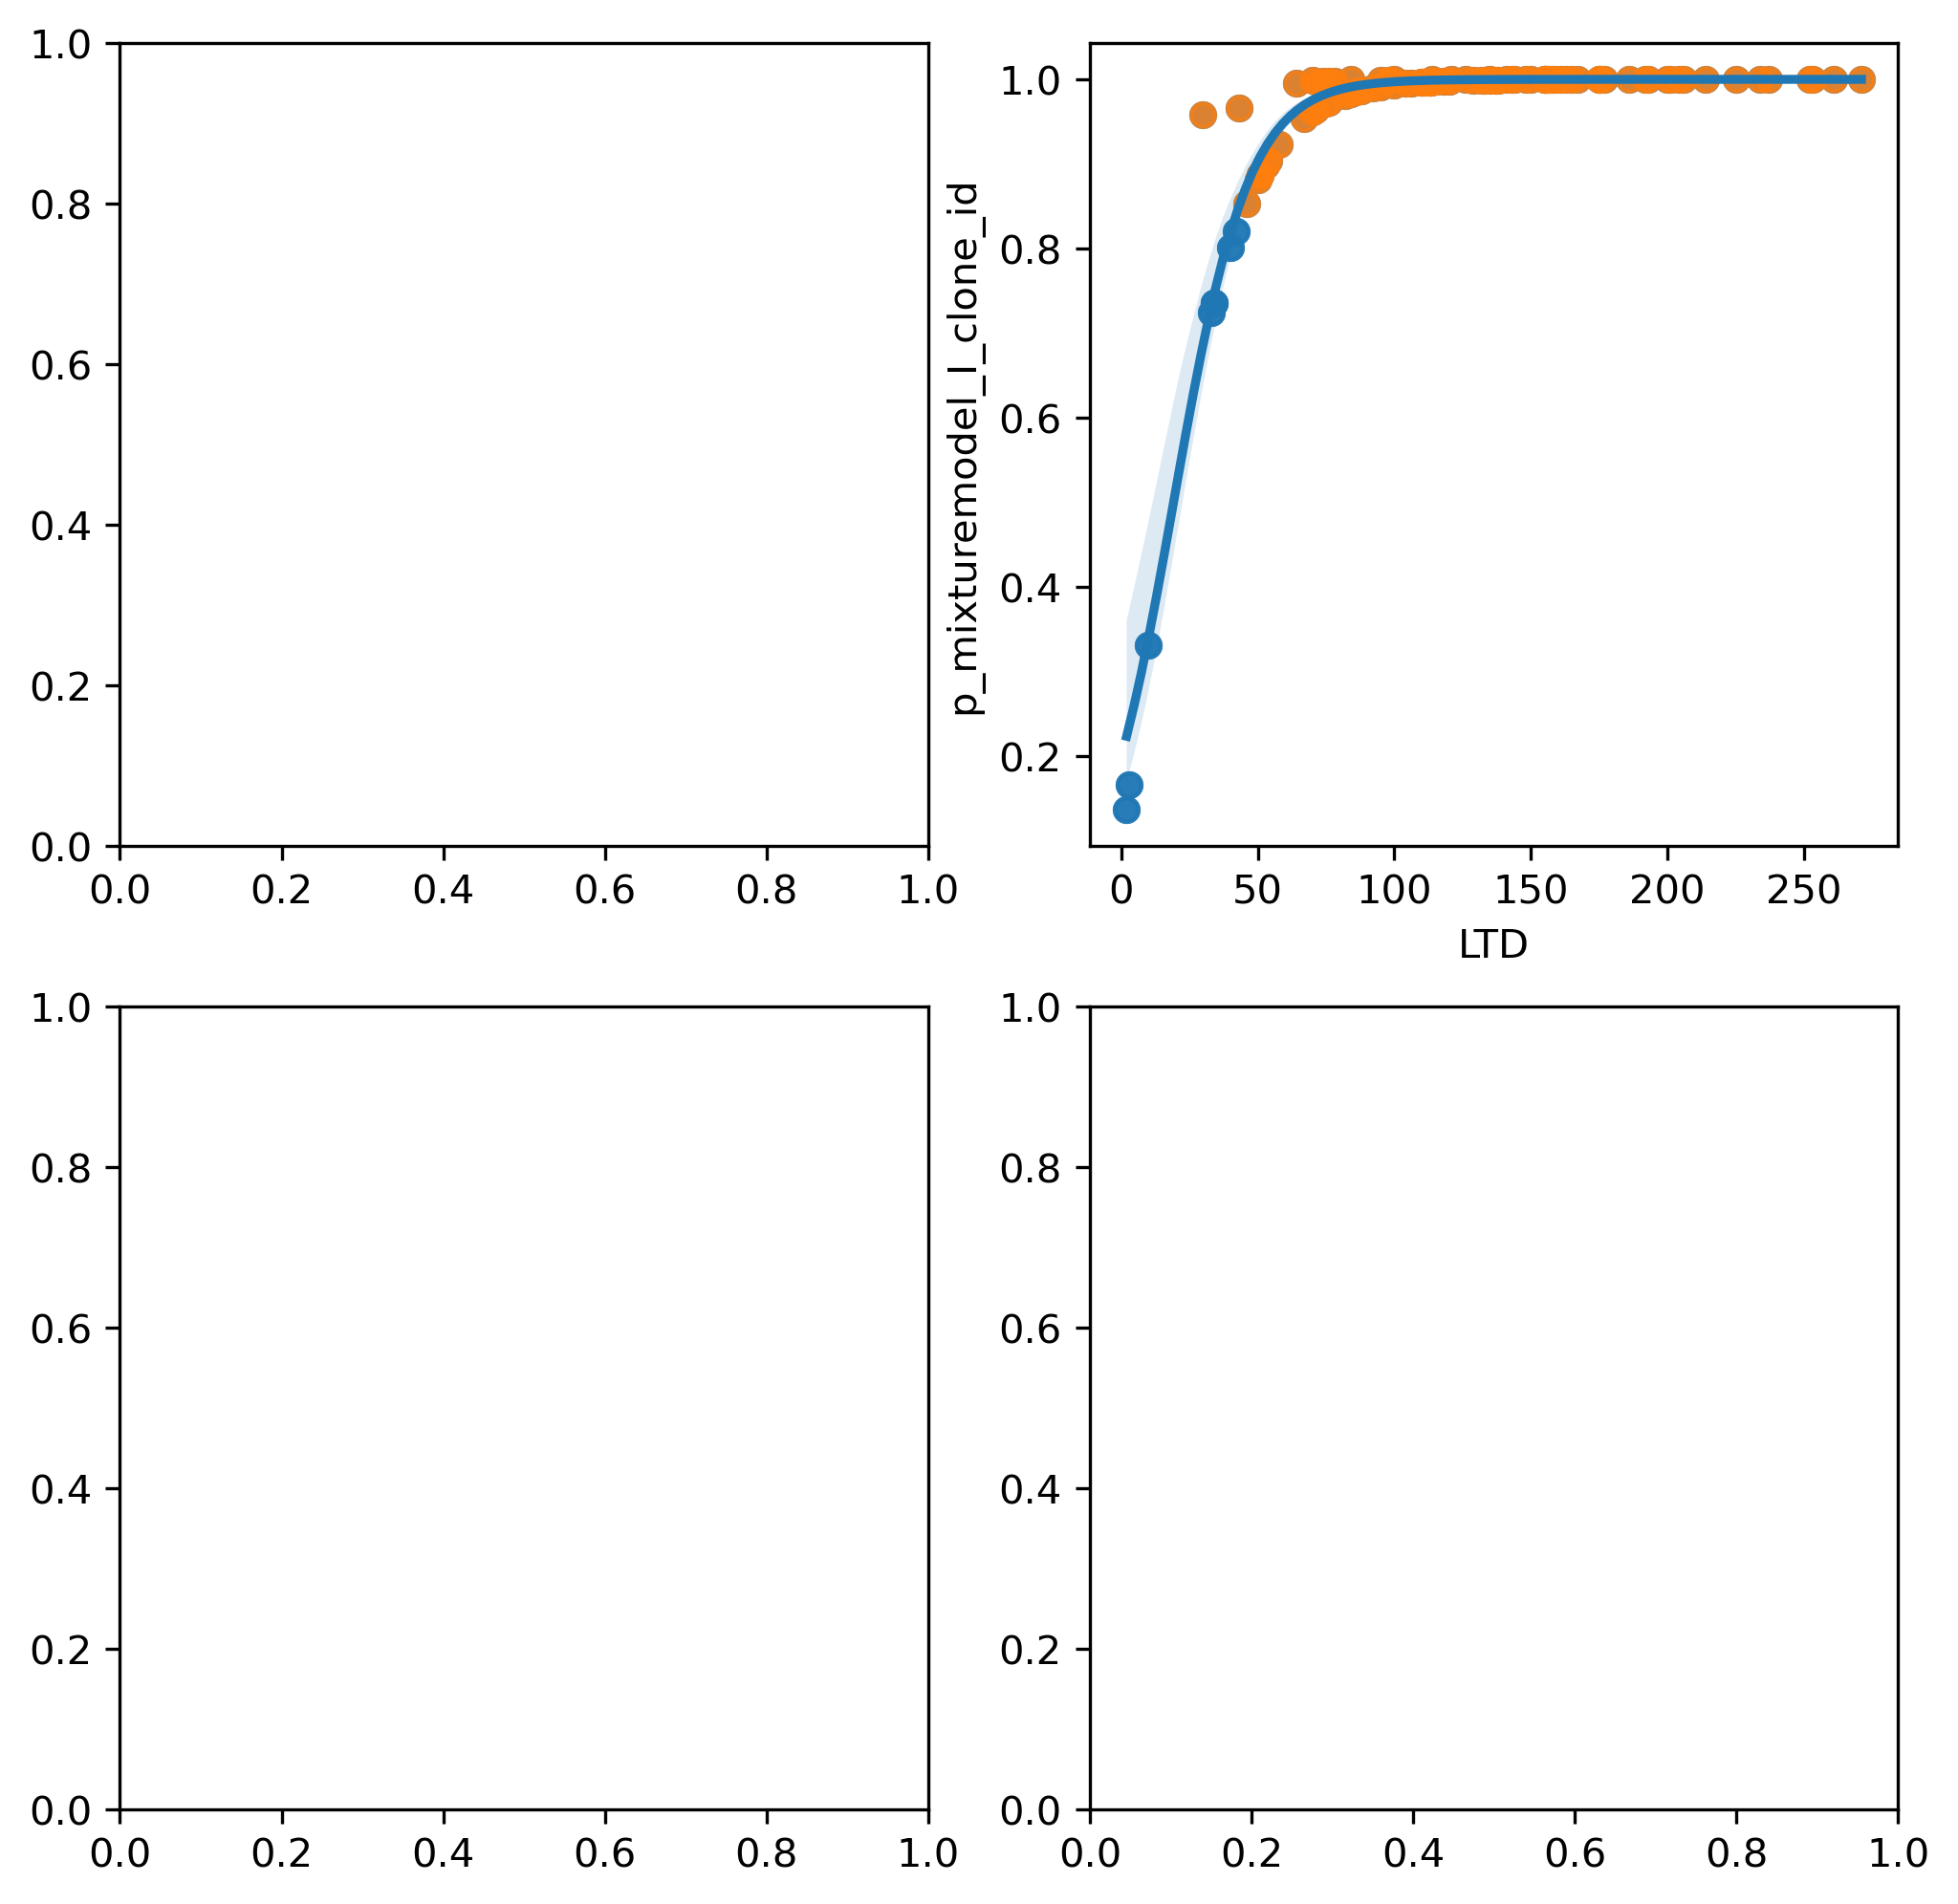

In [11]:
def hue_regplot(data, x, y, hue, palette=None, **kwargs):
    from matplotlib import colormaps
    
    regplots = []
    
    levels = data[hue].unique()[::-1]
    
    if palette is None:
        default_colors = colormaps["tab10"]
        palette = {k: default_colors(i) for i, k in enumerate(levels)}
    
    for key in levels:
        regplots.append(
            sns.regplot(
                x=x,
                y=y,
                data=data[data[hue] == key],
                color=palette[key],
                **kwargs
            )
        )
    
    return regplots


exp_results = pd.read_excel("Determined TCR avidity_Katha.xlsx", header=0, sheet_name="Updated_241007_individual_Donor")
exp_results = exp_results[exp_results.donor != "A29"]
unreactive_clones = ['10623.0', '4350.0', '2123.0', '1690.0', '9973.0']



model="mixturemodel"
mode="I"
clone="clone_id"

mixer = DextraMixer(model_type=model, mode=mode)
mixer.preprocess_model_data(mdat_LTD, pmhc_key="LTDEMIAQY", gex_key="dex", ir_clone_key="clone_id")

num_steps = 10000

trace = mixer.fit_svi(rng_key=42, svi_config= {"maxiter": num_steps})
p, assignment = mixer.predict_posterior_class(target_fdr=0.05)

mdat_LTD.mod["airr"].obs[f"p_{model}_{mode}_{clone}"] = p
mdat_LTD.mod["airr"].obs[f"assignment_{model}_{mode}_{clone}"] = assignment
mdat_LTD.mod["airr"].uns[f"summary_{model}_{mode}_{clone}"] = mixer.summary()

df_airr = mdat_LTD.mod["airr"].obs[["clone_id_felix", f"p_{model}_{mode}_{clone}", f"assignment_{model}_{mode}_{clone}"]]
df_airr["LTD"] = mdat_LTD.mod["dex"].X[:,0]
df_airr["clone_id_felix"] = df_airr["clone_id_felix"].astype("float") 
df = pd.merge(exp_results, df_airr, how="inner", left_on="Clone", right_on="clone_id_felix")

clone_precision = len(df_airr[df_airr[f"assignment_{model}_{mode}_{clone}"] == 1]["clone_id_felix"].unique()) / len(df_airr["clone_id_felix"].unique())
mdat_LTD.mod["airr"].uns[f"metrics_{model}_{mode}_{clone}"] = {"total":len(df), 
                                                                           "TP":np.sum(df[f"assignment_{model}_{mode}_{clone}"]),
                                                                           "FN":np.sum(df[f"assignment_{model}_{mode}_{clone}"] != 1), 
                                                                           "recall":np.sum(df[f"assignment_{model}_{mode}_{clone}"])/len(df),
                                                                           "clonal_precision":clone_precision 
                                                                          }
print("Metrics", mdat_LTD.mod["airr"].uns[f"metrics_{model}_{mode}_{clone}"])

fig, axs = plt.subplots(nrows=2, ncols=2, sharey=False, figsize=(8,8), dpi=300)
sns.regplot(x="LTD", y=f"p_{model}_{mode}_{clone}", data=df, scatter=True, logistic=True, ax=axs[0,1])
ax = hue_regplot(data=df, x="LTD", y=f"p_{model}_{mode}_{clone}",hue=f"assignment_{model}_{mode}_{clone}", 
                 fit_reg=False, truncate=False, ax=axs[0,1]);

# Run inference for all modells

In [ ]:
from dextramixer.model import BEAMT

def hue_regplot(data, x, y, hue, palette=None, **kwargs):
    from matplotlib import colormaps
    
    regplots = []
    
    levels = data[hue].unique()[::-1]
    
    if palette is None:
        default_colors = colormaps["tab10"]
        palette = {k: default_colors(i) for i, k in enumerate(levels)}
    
    for key in levels:
        regplots.append(
            sns.regplot(
                x=x,
                y=y,
                data=data[data[hue] == key],
                color=palette[key],
                **kwargs
            )
        )
    
    return regplots


exp_results = pd.read_excel("Determined TCR avidity_Katha.xlsx", header=0, sheet_name="Updated_241007_individual_Donor")
exp_results = exp_results[exp_results.donor != "A29"]
unreactive_clones = ['10623.0', '4350.0', '2123.0', '1690.0', '9973.0']

for model in ["mixturemodel", "mixturemodelkmeans"]:
    for mode in ["H", "I", "C"]:
        for clone in ["clone_id", None]:

            if model == "BEAMT": 
            
                if(mode != "H" or clone is None):
                    continue
                else:
                    mode = None

            if mode == "C" and clone is None:
                continue

            print(f"inference for model: {model}_{mode}_{clone}")
            mixer = DextraMixer(model_type=model, mode=mode)


            mixer.preprocess_model_data(mdat_LTD, pmhc_key="LTDEMIAQY", gex_key="dex", ir_clone_key=clone)
            if model == "BEAMT":
                trace = mixer.fit(rng_key=42)
            else:
                trace = mixer.fit_svi(rng_key=42, svi_config= {"maxiter": 2000})

            p, assignment = mixer.predict_posterior_class(target_fdr=0.05)

            mdat_LTD.mod["airr"].obs[f"p_{model}_{mode}_{clone}"] = p
            mdat_LTD.mod["airr"].obs[f"assignment_{model}_{mode}_{clone}"] = assignment
            mdat_LTD.mod["airr"].uns[f"summary_{model}_{mode}_{clone}"] = mixer.summary()

            print("summary\n", mdat_LTD.mod["airr"].uns[f"summary_{model}_{mode}_{clone}"])

            fig, axs = plt.subplots(nrows=2, ncols=2, sharey=False, figsize=(8,8), dpi=300)
            df = pd.DataFrame.from_dict({"LTD":mdat_LTD.mod["dex"].X[:,0], "binder":assignment})
            sns.histplot(data=df,x="LTD", hue="binder", fill=True,log_scale=False, common_norm=True, alpha=.5, linewidth=0, ax=axs[0,0])

            df_airr = mdat_LTD.mod["airr"].obs[["clone_id_felix", f"p_{model}_{mode}_{clone}", f"assignment_{model}_{mode}_{clone}"]]
            df_airr["LTD"] = mdat_LTD.mod["dex"].X[:,0]
            df_airr["clone_id_felix"] = df_airr["clone_id_felix"].astype("float") 
            df = pd.merge(exp_results, df_airr, how="inner", left_on="Clone", right_on="clone_id_felix")

            clone_precision = len(df_airr[df_airr[f"assignment_{model}_{mode}_{clone}"] == 1]["clone_id_felix"].unique()) / len(df_airr["clone_id_felix"].unique())
            mdat_LTD.mod["airr"].uns[f"metrics_{model}_{mode}_{clone}"] = {"total":len(df), 
                                                                           "TP":np.sum(df[f"assignment_{model}_{mode}_{clone}"]),
                                                                           "FN":np.sum(df[f"assignment_{model}_{mode}_{clone}"] != 1), 
                                                                           "recall":np.sum(df[f"assignment_{model}_{mode}_{clone}"])/len(df),
                                                                           "clonal_precision":clone_precision 
                                                                          }
            print("Metrics", mdat_LTD.mod["airr"].uns[f"metrics_{model}_{mode}_{clone}"])

            mdat_LTD.write("mdat_LTD_{}.h5mu".format(experiment))

            sns.regplot(x="LTD", y=f"p_{model}_{mode}_{clone}", data=df, scatter=True, logistic=True, ax=axs[0,1])
            ax = hue_regplot(data=df, x="LTD", y=f"p_{model}_{mode}_{clone}",hue=f"assignment_{model}_{mode}_{clone}", 
                             fit_reg=False, truncate=False, ax=axs[0,1]);
            
            ax = hue_regplot(data=df, x="LTD", y="mTRBC EC50",hue=f"assignment_{model}_{mode}_{clone}", ax=axs[1,0]);
            ax = hue_regplot(data=df, x="LTD", y="IFNg EC50",hue=f"assignment_{model}_{mode}_{clone}",  ax=axs[1,1]);
            
            plt.savefig(f"./fig_{model}_{mode}_{clone}.pdf")



In [ ]:
import numpyro

numpyro.set_host_device_count(6)

mixer = DextraMixer(model_type="mixturemodel", mode="I")
#ir_cov_key="ir_alignment_cov"
mixer.preprocess_model_data(mdat_LTD, pmhc_key="LTDEMIAQY", gex_key="dex", ir_clone_key="clone_id")
trace = mixer.fit_svi(numpyro.infer.autoguide.AutoNormal, rng_key=42)
mixer.summary()

In [ ]:
p, assignment = mixer.predict_posterior_class(target_fdr=0.05)
np.sum(assignment), np.min(p), np.max(p), np.median(p)

In [ ]:
mdat_LTD.mod["airr"].obs["p_I_Clone"] = p
mdat_LTD.mod["airr"].obs["assignment_I_Clone"] = assignment
mdat_LTD.mod["airr"].uns["I_Clone_summary"] = mixer.summary()
mdat_LTD.write("mdat_LTD_{}.h5mu".format(experiment))

In [ ]:
df = pd.DataFrame.from_dict({"counts":mdat_LTD.mod["dex"].X[:,0], "binder":assignment})
sns.histplot(data=df,x="counts", hue="binder", fill=True,log_scale=False, common_norm=False, alpha=.5, linewidth=0)

In [ ]:
df = pd.DataFrame.from_dict({"counts":mdat_LTD.mod["dex"].X[:,0], "binder":assignment, "p":p})
g = sns.jointplot(
    data=df,
    y="p", x="counts", hue="binder",
    fill=False,
    kind="kde",
    thresh=None,
)

# Experimental Verification

In [ ]:
exp_results = pd.read_excel("Determined TCR avidity_Katha.xlsx", header=0)
exp_results = exp_results[exp_results.donor != "A29"]
unreactive_clones = ['10623.0', '4350.0', '2123.0', '1690.0', '9973.0']

In [ ]:
mdat_LTD.mod["airr"].obs["clone_id_felix"]

In [ ]:
exp_results[exp_results.Clone.isin(mdat_LTD.mod["airr"].obs["clone_id_felix"].astype("float"))]

In [ ]:
df_airr = mdat_LTD.mod["airr"].obs[["clone_id_felix", "p_I_Clone", "assignment_I_Clone"]]
df_airr["LTD"] = mdat_LTD.mod["dex"].X[:,0]
df_airr["clone_id_felix"] = df_airr["clone_id_felix"].astype("float") 
df = pd.merge(exp_results, df_airr, how="inner", left_on="Clone", right_on="clone_id_felix")
df

In [ ]:
ax = sns.lmplot(data=df, x="LTD", y="mTRBC EC50",hue="assignment_I_Clone", markers=["x", "o"]);
#sns.regplot(x="LTD", y="mTRBC EC50", data=df, scatter=False, logistic=False)

In [ ]:
ax = sns.lmplot(data=df, x="LTD", y="IFNg EC50",hue="assignment_I_Clone", fit_reg=False, truncate=False);
sns.regplot(x="LTD", y="IFNg EC50", data=df, scatter=False, logistic=False, ax=ax.axes[0, 0])

In [ ]:
ax = sns.lmplot(data=df, x="IFNg EC50", y="assignment_I_Clone",  logistic=True, truncate=False);
p1 = plt.gca()
for  i,row in df.iterrows():
     if row.assignment_I_Clone == 0:
         p1.text(row["IFNg EC50"]+1e-8, row.assignment_I_Clone+0.01, row.Clone, horizontalalignment='left', rotation=40)

In [ ]:
ax = sns.lmplot(data=df, x="mTRBC EC50", y="assignment_I_Clone",  logistic=True, truncate=False);
p1 = plt.gca()
for  i,row in df.iterrows():
     if row.assignment_I_Clone == 0:
         p1.text(row["mTRBC EC50"]+1e-8, row.assignment_I_Clone+0.01, row.Clone, horizontalalignment='left', rotation=40)

In [ ]:
import matplotlib.pyplot as plt

ax = sns.lmplot(data=df, x="LTD", y="assignment_I_Clone",  logistic=True, truncate=False);
p1 = plt.gca()
for  i,row in df.iterrows():
     if row.assignment_I_Clone == 0:
         p1.text(row["LTD"]+1e-8, row.assignment_I_Clone+0.01, row.Clone, horizontalalignment='left', rotation=40)

In [ ]:
ax = sns.lmplot(data=df, x="LTD", y="p_I_Clone",hue="assignment_I_Clone", fit_reg=False, truncate=False);
sns.regplot(x="LTD", y="p_I_Clone", data=df, scatter=True, logistic=True, ax=ax.axes[0, 0])


In [ ]:
def hue_regplot(data, x, y, hue, palette=None, **kwargs):
    from matplotlib import colormaps
    
    regplots = []
    
    levels = data[hue].unique()[::-1]
    
    if palette is None:
        default_colors = colormaps["tab10"]
        palette = {k: default_colors(i) for i, k in enumerate(levels)}
    
    for key in levels:
        regplots.append(
            sns.regplot(
                x=x,
                y=y,
                data=data[data[hue] == key],
                color=palette[key],
                **kwargs
            )
        )
    
    return regplots

In [ ]:
            mode,clone = "I","Clone"
            fig, axs = plt.subplots(nrows=2, ncols=2, sharey=False, figsize=(8,8), dpi=300)
            df = pd.DataFrame.from_dict({"LTD":mdat_LTD.mod["dex"].X[:,0], "binder":assignment})
            sns.histplot(data=df,x="LTD", hue="binder", fill=True,log_scale=False, common_norm=True, alpha=.5, linewidth=0, ax=axs[0,0])

            df_airr = mdat_LTD.mod["airr"].obs[["clone_id_felix", f"p_{mode}_{clone}", f"assignment_{mode}_{clone}"]]
            df_airr["LTD"] = mdat_LTD.mod["dex"].X[:,0]
            df_airr["clone_id_felix"] = df_airr["clone_id_felix"].astype("float") 
            df = pd.merge(exp_results, df_airr, how="inner", left_on="Clone", right_on="clone_id_felix")
            
            sns.regplot(x="LTD", y="p_I_Clone", data=df, scatter=True, logistic=True, ax=axs[0,1])
            ax = hue_regplot(data=df, x="LTD", y="p_I_Clone",hue="assignment_I_Clone", fit_reg=False, truncate=False, ax=axs[0,1]);
            
            ax = hue_regplot(data=df, x="LTD", y="mTRBC EC50",hue=f"assignment_{mode}_{clone}", ax=axs[1,0]);
            ax = hue_regplot(data=df, x="LTD", y="IFNg EC50",hue=f"assignment_{mode}_{clone}",  ax=axs[1,1]);



In [ ]:
print("Total", len(df), "TP",np.sum(df.assignment_I_Clone),"FP", np.sum(df.assignment_I_Clone != 1), "Recall", np.sum(df.assignment_I_Clone)/len(df))

In [ ]:
df_unreactive = mdat_LTD.mod["airr"].obs[mdat_LTD.mod["airr"].obs["clone_id_felix"].isin(unreactive_clones)]
df_unreactive

In [ ]:
mdat_LTD.mod["dex"][df_unreactive.index].X

In [ ]:
mdat_LTD_binder = mdat_LTD[mdat_LTD.mod["airr"].obs["assignment_H_Cov"] == 1]
mdat_LTD_binder

with ir.get.airr_context(mdat_LTD_binder, "junction_aa", ["VJ_1", "VDJ_1", "VJ_2", "VDJ_2"]):
    binder = (
         mdat_LTD_binder.obs
        .astype(str)
        .groupby(
            [
                "VJ_1_junction_aa",
                "VDJ_1_junction_aa",
                "VJ_2_junction_aa",
                "VDJ_2_junction_aa",
                "airr:receptor_subtype",
            ],
            observed=True,
            dropna=False,
        )
        .size()
        .reset_index(name="n_cells")
    )
binder

In [ ]:
ir.pl.spectratype(mdat_LTD, color="airr:assignment_H_Cov", viztype="bar", fig_kws={"dpi": 120})

In [ ]:
mdat_LTD_binder

In [ ]:
from palmotif import compute_motif, svg_logo

motif = compute_motif(np.unique(binder[binder["VDJ_1_junction_aa"].str.len() == 14]["VDJ_1_junction_aa"]).tolist())
_ = svg_logo(
    motif, "./logo_second_experiment_binder_H_Cov.svg", color_scheme="taylor"
)

In [ ]:
mdat_LTD_nonbinder = mdat_LTD[mdat_LTD.mod["airr"].obs["assignment_H_Cov"] == 0]
mdat_LTD_nonbinder

with ir.get.airr_context(mdat_LTD_nonbinder, "junction_aa", ["VJ_1", "VDJ_1", "VJ_2", "VDJ_2"]):
    nonbinder = (
         mdat_LTD_nonbinder.obs
        .astype(str)
        .groupby(
            [
                "VJ_1_junction_aa",
                "VDJ_1_junction_aa",
                "VJ_2_junction_aa",
                "VDJ_2_junction_aa",
                "airr:receptor_subtype",
            ],
            observed=True,
            dropna=False,
        )
        .size()
        .reset_index(name="n_cells")
    )
nonbinder

In [ ]:
from palmotif import compute_motif, svg_logo

motif = compute_motif(np.unique(nonbinder[nonbinder["VDJ_1_junction_aa"].str.len() == 14]["VDJ_1_junction_aa"]).tolist())
_ = svg_logo(
    motif, "./logo_second_experiment_nonbinder_H_Cov.svg", color_scheme="taylor"
)

In [ ]:
aa_alphabet = [aa for aa in 'ARNDCQEGHILKMFPSTWYVBZX-']
search_patter= []
for j in range(motif.shape[1]):
    idx = np.where(motif[j] >0.05)[0]
    print(idx)
    a = aa_alphabet[idx[0]] if len(idx) == 1 else "[{}]".format("".join(aa_alphabet[i] for i in idx))
    search_patter.append(a)
print("".join(search_patter))
        

In [ ]:
with ir.get.airr_context(mdat_LTD, "junction_aa", ["VJ_1", "VDJ_1", "VJ_2", "VDJ_2"]):
    clone_475 = (mdat_LTD.obs.loc[lambda x: x["airr:clone_id_felix"] == "475.0"]
    .astype(str)
    .groupby(
            [
                "VJ_1_junction_aa",
                "VDJ_1_junction_aa",
                "VJ_2_junction_aa",
                "VDJ_2_junction_aa",
                "airr:receptor_subtype",
            ],
            observed=True,
            dropna=False,
        )
        .size()
        .reset_index(name="n_cells")
    )
clone_475